# Car Price Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("auto.csv")

In [3]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250


To check all data types

In [4]:
df.dtypes

symboling              int64
normalized-losses        str
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                     str
stroke                   str
compression-ratio    float64
horsepower               str
peak-rpm                 str
city-mpg               int64
highway-mpg            int64
price                    str
dtype: object

# Only describes about numeric data types


In [5]:
df.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000
mean,0.823529,98.806373,174.075000,65.916667,53.749020,2555.602941,126.892157,10.148137,25.240196,30.769608
std,1.239035,5.994144,12.362123,2.146716,2.424901,521.960820,41.744569,3.981000,6.551513,6.898337
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.075000,52.000000,2145.000000,97.000000,8.575000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,119.500000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.200000,66.900000,55.500000,2939.250000,142.000000,9.400000,30.000000,34.500000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


In [6]:
df.describe(include='all')

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,204.000000,204,204,204,204,204,204,204,204,204.000000,...,204.000000,204,204,204,204.000000,204,204,204.000000,204.000000,204
unique,NaN,52,22,2,2,3,5,3,2,NaN,...,NaN,8,39,37,NaN,60,24,NaN,NaN,186
top,NaN,?,toyota,gas,std,four,sedan,fwd,front,NaN,...,NaN,mpfi,3.62,3.40,NaN,68,5500,NaN,NaN,?
freq,NaN,40,32,184,167,114,96,120,201,NaN,...,NaN,93,23,20,NaN,19,37,NaN,NaN,4
mean,0.823529,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.806373,...,126.892157,NaN,NaN,NaN,10.148137,NaN,NaN,25.240196,30.769608,NaN
std,1.239035,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.994144,...,41.744569,NaN,NaN,NaN,3.981000,NaN,NaN,6.551513,6.898337,NaN
min,-2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.600000,...,61.000000,NaN,NaN,NaN,7.000000,NaN,NaN,13.000000,16.000000,NaN
25%,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.500000,...,97.000000,NaN,NaN,NaN,8.575000,NaN,NaN,19.000000,25.000000,NaN
50%,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.000000,...,119.500000,NaN,NaN,NaN,9.000000,NaN,NaN,24.000000,30.000000,NaN
75%,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.400000,...,142.000000,NaN,NaN,NaN,9.400000,NaN,NaN,30.000000,34.500000,NaN


## Only describes about object type

In [7]:
df.describe(include='object')

,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system,bore,stroke,horsepower,peak-rpm,price
count,204,204,204,204,204,204,204,204,204,204,204,204,204,204,204,204
unique,52,22,2,2,3,5,3,2,7,7,8,39,37,60,24,186
top,?,toyota,gas,std,four,sedan,fwd,front,ohc,four,mpfi,3.62,3.40,68,5500,?
freq,40,32,184,167,114,96,120,201,148,158,93,23,20,19,37,4


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          204 non-null    int64  
 1   normalized-losses  204 non-null    str    
 2   make               204 non-null    str    
 3   fuel-type          204 non-null    str    
 4   aspiration         204 non-null    str    
 5   num-of-doors       204 non-null    str    
 6   body-style         204 non-null    str    
 7   drive-wheels       204 non-null    str    
 8   engine-location    204 non-null    str    
 9   wheel-base         204 non-null    float64
 10  length             204 non-null    float64
 11  width              204 non-null    float64
 12  height             204 non-null    float64
 13  curb-weight        204 non-null    int64  
 14  engine-type        204 non-null    str    
 15  num-of-cylinders   204 non-null    str    
 16  engine-size        204 non-null    in

## NOW WE WANT TO FIGURE OUT NUMERIC AND OBJECT COLUMNS SEPARATELY

In [9]:
num_col=df.select_dtypes(include='number').columns.tolist()
obj_col=df.select_dtypes(include='object').columns.tolist()
print("Numeric Columns:", num_col)
print("Numeric Columns Number:", len(num_col))
print("\nObject Columns:", obj_col)
print("Object Columns Number:", len(obj_col))

Numeric Columns: ['symboling', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'compression-ratio', 'city-mpg', 'highway-mpg']
Numeric Columns Number: 10

Object Columns: ['normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']
Object Columns Number: 16


###Identify and handle missing values
##Identify missing values
##Convert "?" to NaN
In the car data set, missing data comes with the question mark "?". We replace "?" with NaN (Not a Number), 
Python's default missing value marker for reasons of computational speed and convenience.

In [10]:
df.replace('?', np.nan, inplace=True)
df.head(5)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,NaN,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250


## Evaluating for Missing Data

In [11]:
missing_values=df.isnull()
missing_values.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Count missing values in each column.

In [12]:
for col in missing_values.columns.tolist():
    print(missing_values[col].value_counts())

symboling
False    204
Name: count, dtype: int64
normalized-losses
False    164
True      40
Name: count, dtype: int64
make
False    204
Name: count, dtype: int64
fuel-type
False    204
Name: count, dtype: int64
aspiration
False    204
Name: count, dtype: int64
num-of-doors
False    202
True       2
Name: count, dtype: int64
body-style
False    204
Name: count, dtype: int64
drive-wheels
False    204
Name: count, dtype: int64
engine-location
False    204
Name: count, dtype: int64
wheel-base
False    204
Name: count, dtype: int64
length
False    204
Name: count, dtype: int64
width
False    204
Name: count, dtype: int64
height
False    204
Name: count, dtype: int64
curb-weight
False    204
Name: count, dtype: int64
engine-type
False    204
Name: count, dtype: int64
num-of-cylinders
False    204
Name: count, dtype: int64
engine-size
False    204
Name: count, dtype: int64
fuel-system
False    204
Name: count, dtype: int64
bore
False    200
True       4
Name: count, dtype: int64
stroke
False

### We have missing values in [normalized-losses,num-of-doors,bore,stroke,horsepower,peak-rpm,price] columns. 
## So what about a one step solution???.

In [13]:
missing_columns=df.isnull().sum()[df.isnull().sum() > 0]
result=pd.DataFrame({
    "Missing_count": missing_columns,
    "Data_type": df[missing_columns.index].dtypes})
print(result)

                   Missing_count Data_type
normalized-losses             40       str
num-of-doors                   2       str
bore                           4       str
stroke                         4       str
horsepower                     2       str
peak-rpm                       2       str
price                          4       str


### Deal with missing data
How should you deal with missing data?
### Drop data
    a. Drop the whole row
    b. Drop the whole column
### Replace data
    a. Replace it by mean.
    b. Replace it by frequency.
    c. Replace it based on other functions.

### Calculate the mean value for the "normalized-losses" column and fill missing values with that

In [14]:
avg_norm_loss=df["normalized-losses"].astype(float).mean(axis=0)

In [15]:
df["normalized-losses"]=df["normalized-losses"].replace(np.nan, avg_norm_loss, inplace=True)
df["normalized-losses"].head()

0    122.0
1    122.0
2      164
3      164
4    122.0
Name: normalized-losses, dtype: object

In [16]:
df["normalized-losses"].isnull().sum()

np.int64(0)

### Calculate the mean value for the "bore" column and fill missing values with that

In [17]:
avg_bore=df['bore'].astype(float).mean(axis=0)

In [18]:
df['bore']=df['bore'].replace(np.nan, avg_bore, inplace=True)
df['bore'].head()

0    3.47
1    2.68
2    3.19
3    3.19
4    3.19
Name: bore, dtype: object

In [19]:
df['bore'].isnull().sum()

np.int64(0)

### Calculate the mean value for the "horsepower" column and fill missing values with that

In [20]:
avg_horsepower = df['horsepower'].astype(float).mean(axis=0)

In [21]:
df['horsepower'].replace(np.nan, avg_horsepower, inplace=True)
df['horsepower'].head()

0    111
1    154
2    102
3    115
4    110
Name: horsepower, dtype: str

In [22]:
df['horsepower'].isnull().sum()

np.int64(2)

### Calculate the mean value for "peak-rpm" column

In [23]:
df["peak-rpm"].value_counts(dropna=False)

peak-rpm
5500    37
4800    36
5000    26
5200    23
5400    13
6000     9
5800     7
4500     7
5250     7
4200     5
4150     5
4750     4
4350     4
4250     3
5100     3
5900     3
4400     3
NaN      2
6600     2
4650     1
5600     1
5750     1
4900     1
5300     1
Name: count, dtype: int64

In [24]:
avg_peakrpm=df['peak-rpm'].astype('float').mean(axis=0)
df['peak-rpm'].replace(np.nan, avg_peakrpm, inplace=True)

0      5000
1      5000
2      5500
3      5500
4      5500
       ... 
199    5400
200    5300
201    5500
202    4800
203    5400
Name: peak-rpm, Length: 204, dtype: object

In [25]:
df.drop([125,126,129,130], inplace=True)

In [26]:
df[df["peak-rpm"].isnull()]

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price


In [27]:
df["peak-rpm"].isnull().sum()

np.int64(0)

In [28]:
df.reset_index(drop=True, inplace=True)

### Calculate the mean value for "stroke" column

In [29]:
df["stroke"] = pd.to_numeric(df["stroke"], errors="coerce")
avg_stroke = df["stroke"].mean()
print("Average stroke:", avg_stroke)
df["stroke"].fillna(avg_stroke, inplace=True)

Average stroke: 3.255408163265306


0      2.68
1      3.47
2      3.40
3      3.40
4      3.40
       ... 
195    3.15
196    3.15
197    2.87
198    3.40
199    3.15
Name: stroke, Length: 200, dtype: float64

In [30]:
df.drop([51,52,53,54,55,56,57],inplace=True)

In [31]:
df.reset_index(drop=True, inplace=True)

In [32]:
df[df[ "stroke"].isnull()]

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price


### Calculate the frequency of number of doors value and fill with that missing values in "num-of-doors" column

In [33]:
df["num-of-doors"].value_counts().idxmax()

'four'

In [34]:
df["num-of-doors"]=df["num-of-doors"].replace(np.nan, "four", inplace=True)

## Finally, drop all rows that do not have price data because we want to predict price of a car based on other variables

In [35]:
df.dropna(subset=['price'], axis=0, inplace=True)
df.reset_index(drop=True, inplace=True)

### Correct data format

In [36]:
df[["normalized-losses"]]=df[["normalized-losses"]].astype(int)        
df[["bore","stroke","peak-rpm","price"]]=df[["bore","stroke","peak-rpm","price"]].astype(float)

# Now let's recheck for missing values

In [37]:
missing_columns=df.isnull().sum()[df.isnull().sum() > 0]
result=pd.DataFrame({
    "Missing_count": missing_columns,
    "Data_type": df[missing_columns.index].dtypes})
print(result)

Empty DataFrame
Columns: [Missing_count, Data_type]
Index: []


In [38]:
df.shape

(189, 26)

# Data Standardization

### Standardization is the process of transforming data into a common format, allowing the researcher to make the meaningful comparison.

In [39]:
df['city-mpg'] = 235/df['city-mpg']
df.rename(columns={'city-mpg':'city-L/100km'}, inplace=True)

In [40]:
df["highway-mpg"] = 235/df["highway-mpg"]
df.rename(columns={"highway-mpg":'highway-L/100km'}, inplace=True)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-L/100km,highway-L/100km,price
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000.0,11.190476,8.703704,16500.0
1,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000.0,12.368421,9.038462,16500.0
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500.0,9.791667,7.833333,13950.0
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500.0,13.055556,10.681818,17450.0
4,2,122,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500.0,12.368421,9.400000,15250.0


# Data Normalization
Normalization is the process of transforming values of several variables into a similar range

In [41]:
df['length'] = df['length']/df['length'].max()
df['width'] = df['width']/df['width'].max()
df['height'] = df['height']/df['height'].max() 

In [42]:
df[["length","width","height"]].head()

,length,width,height
0,0.811148,0.890278,0.816054
1,0.822681,0.909722,0.876254
2,0.848630,0.919444,0.908027
3,0.848630,0.922222,0.908027
4,0.851994,0.920833,0.887960


# Binning
### Binning is a process of transforming continuous numerical variables into discrete categorical 'bins' for grouped analysis.

In [43]:
df["horsepower"]=df["horsepower"].astype(int, copy=True)

Text(0.5, 1.0, 'horsepower bins')

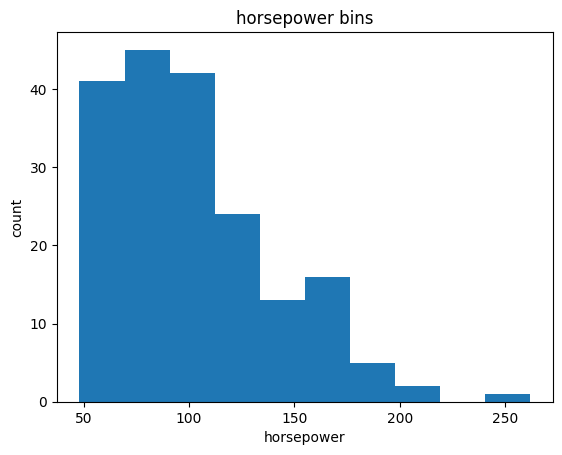

In [44]:
import matplotlib as plt
from matplotlib import pyplot
plt.pyplot.hist(df["horsepower"])

# set x/y labels and plot title
plt.pyplot.xlabel("horsepower")
plt.pyplot.ylabel("count")
plt.pyplot.title("horsepower bins")

### Let's divide horsepower into 3 categories

In [45]:
bins=np.linspace(min(df['horsepower']),max(df['horsepower']),4)

In [46]:
group_names = ['Low', 'Medium', 'High']

In [47]:
df['binned-horsepower']=pd.cut(df['horsepower'], bins, labels=group_names,include_lowest=True)
df[['horsepower','binned-horsepower']].head(10)

,horsepower,binned-horsepower
0,111,Low
1,154,Medium
2,102,Low
3,115,Low
4,110,Low
5,110,Low
6,110,Low
7,140,Medium
8,101,Low
9,101,Low


In [48]:
df["binned-horsepower"].value_counts()

binned-horsepower
Low       144
Medium     42
High        3
Name: count, dtype: int64

Text(0.5, 1.0, 'horsepower bins')

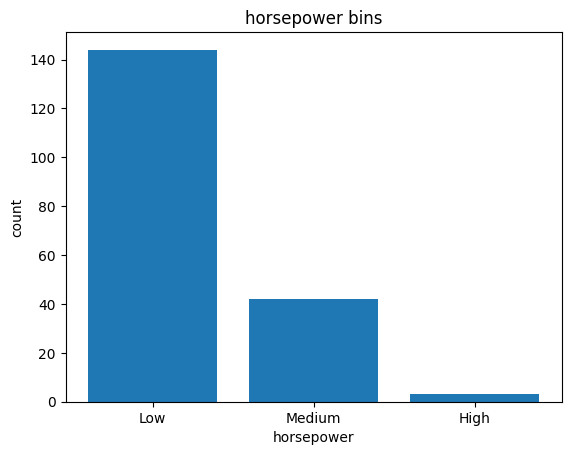

In [49]:
import matplotlib as plt
from matplotlib import pyplot
pyplot.bar(group_names, df["binned-horsepower"].value_counts())
plt.pyplot.xlabel("horsepower")
plt.pyplot.ylabel("count")
plt.pyplot.title("horsepower bins")

# Indicator Variable

### An indicator variable (or dummy variable) is a numerical variable used to label categories. They are called 'dummies' because the numbers themselves don't have inherent meaning.

### Example
The column "fuel-type" has two unique values: "gas" or "diesel". Regression doesn't understand words, only numbers. To use this attribute in regression analysis, you can convert "fuel-type" to indicator variables.

In [50]:
dummy_var1=pd.get_dummies(df['fuel-type'])
dummy_var1.head()

,diesel,gas
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True


In [51]:
dummy_var1.rename(columns={'gas':'fuel_type_gas','diesel':'fuel_type_diesel'}, inplace=True)
dummy_var1.head()

,fuel_type_diesel,fuel_type_gas
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True


In [52]:
df = pd.concat([df, dummy_var1], axis=1)

In [53]:
df.drop('fuel-type', axis=1, inplace=True)
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,stroke,compression-ratio,horsepower,peak-rpm,city-L/100km,highway-L/100km,price,binned-horsepower,fuel_type_diesel,fuel_type_gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,2.68,9.0,111,5000.0,11.190476,8.703704,16500.0,Low,False,True
1,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,3.47,9.0,154,5000.0,12.368421,9.038462,16500.0,Medium,False,True
2,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,3.40,10.0,102,5500.0,9.791667,7.833333,13950.0,Low,False,True
3,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,3.40,8.0,115,5500.0,13.055556,10.681818,17450.0,Low,False,True
4,2,122,audi,std,two,sedan,fwd,front,99.8,0.851994,...,3.40,8.5,110,5500.0,12.368421,9.400000,15250.0,Low,False,True


### Similar to before, create an indicator variable for the column "aspiration"

In [54]:
dummy_var2=pd.get_dummies(df["aspiration"])


In [55]:
dummy_var2.rename(columns={'std':'aspiration-std', 'turbo': 'aspiration-turbo'}, inplace=True)
df=pd.concat([df,dummy_var2], axis=1)
df.drop('aspiration', axis=1, inplace=True)
df.head()

,symboling,normalized-losses,make,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,horsepower,peak-rpm,city-L/100km,highway-L/100km,price,binned-horsepower,fuel_type_diesel,fuel_type_gas,aspiration-std,aspiration-turbo
0,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.811148,0.890278,...,111,5000.0,11.190476,8.703704,16500.0,Low,False,True,True,False
1,1,122,alfa-romero,two,hatchback,rwd,front,94.5,0.822681,0.909722,...,154,5000.0,12.368421,9.038462,16500.0,Medium,False,True,True,False
2,2,164,audi,four,sedan,fwd,front,99.8,0.848630,0.919444,...,102,5500.0,9.791667,7.833333,13950.0,Low,False,True,True,False
3,2,164,audi,four,sedan,4wd,front,99.4,0.848630,0.922222,...,115,5500.0,13.055556,10.681818,17450.0,Low,False,True,True,False
4,2,122,audi,two,sedan,fwd,front,99.8,0.851994,0.920833,...,110,5500.0,12.368421,9.400000,15250.0,Low,False,True,True,False


# Exploratory Data Analysis

## Objectives
    Explore features or characteristics to predict price of car
    Analyze patterns and run descriptive statistical analysis
    Group data based on identified parameters and create pivot tables
    Identify the effect of independent attributes on price of cars

### Analyzing Individual Feature Patterns Using Visualization

### we can calculate the correlation between variables of type "int64" or "float64" using the method "corr"

In [58]:
numeric_df=df.select_dtypes(include=["int64","float64"])
numeric_df.corr()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-L/100km,highway-L/100km,price
symboling,1.000000,0.467627,-0.515184,-0.360302,-0.238453,-0.501272,-0.242650,-0.100491,-0.184445,0.028199,-0.179198,0.023807,0.209754,-0.023265,-0.092619,-0.137299
normalized-losses,0.467627,1.000000,-0.053336,0.022388,0.085572,-0.364369,0.099874,0.136910,-0.037083,0.055835,-0.114084,0.221505,0.218138,0.216619,0.160119,0.136335
wheel-base,-0.515184,-0.053336,1.000000,0.886773,0.821564,0.585455,0.801740,0.610716,0.537210,0.138673,0.244841,0.439583,-0.344464,0.554731,0.626255,0.656381
length,-0.360302,0.022388,0.886773,1.000000,0.857006,0.499974,0.884934,0.702317,0.621776,0.107676,0.156251,0.618291,-0.282761,0.707941,0.736040,0.729337
width,-0.238453,0.085572,0.821564,0.857006,1.000000,0.310990,0.871016,0.757028,0.556319,0.173494,0.186884,0.653698,-0.253468,0.713262,0.757811,0.791357
height,-0.501272,-0.364369,0.585455,0.499974,0.310990,1.000000,0.321777,0.050566,0.219416,-0.089034,0.261174,-0.057403,-0.257403,0.090523,0.147796,0.173526
curb-weight,-0.242650,0.099874,0.801740,0.884934,0.871016,0.321777,1.000000,0.861843,0.641868,0.175524,0.152448,0.777913,-0.297473,0.820968,0.855041,0.853656
engine-size,-0.100491,0.136910,0.610716,0.702317,0.757028,0.050566,0.861843,1.000000,0.566525,0.234747,0.023964,0.839494,-0.259058,0.818018,0.841505,0.887076
bore,-0.184445,-0.037083,0.537210,0.621776,0.556319,0.219416,0.641868,0.566525,1.000000,-0.051570,0.001832,0.546852,-0.318797,0.552162,0.558346,0.525803
stroke,0.028199,0.055835,0.138673,0.107676,0.173494,-0.089034,0.175524,0.234747,-0.051570,1.000000,0.196893,0.137794,-0.053010,0.055937,0.062716,0.125794


In [59]:
#we can find correlation between some specific groups
df[['bore', 'stroke', 'compression-ratio', 'horsepower']].corr()

,bore,stroke,compression-ratio,horsepower
bore,1.000000,-0.051570,0.001832,0.546852
stroke,-0.051570,1.000000,0.196893,0.137794
compression-ratio,0.001832,0.196893,1.000000,-0.224070
horsepower,0.546852,0.137794,-0.224070,1.000000


In [60]:
#we can find correlation 2 specific columns to be more precised
df[['engine-size','price']].corr()

,engine-size,price
engine-size,1.000000,0.887076
price,0.887076,1.000000


### Let's find out how strong these relationships are by visual plots

### For Numeric Columns

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

### Positive Linear Relationship

(0.0, 53760.143040639814)

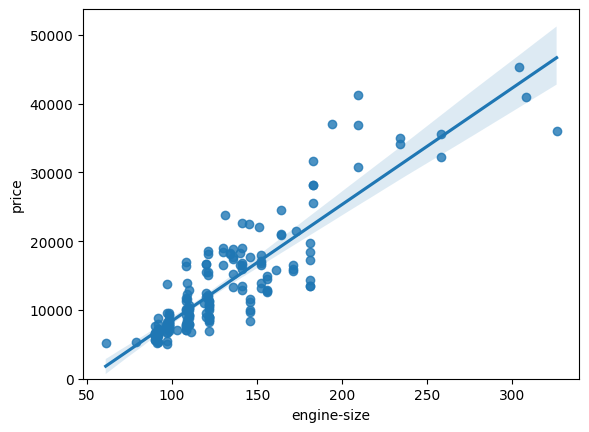

In [65]:
sns.regplot(x='engine-size', y='price', data=df)
plt.ylim(0,)

### Weak Linear Relationship

<Axes: xlabel='peak-rpm', ylabel='price'>

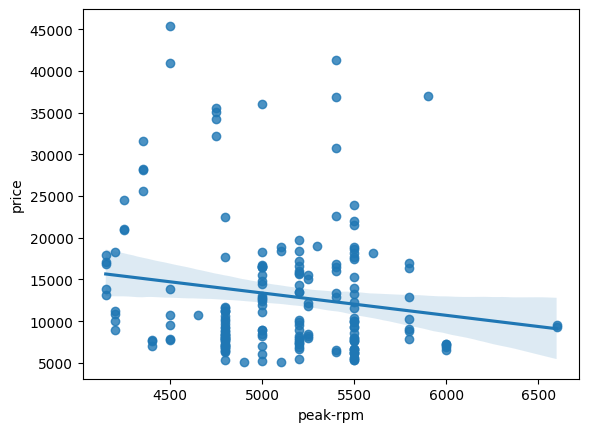

In [66]:
sns.regplot(x="peak-rpm", y="price", data=df)

In [67]:
df[['peak-rpm','price']].corr()

,peak-rpm,price
peak-rpm,1.00000,-0.15924
price,-0.15924,1.00000


### Foe Categorical Variables

<Axes: xlabel='body-style', ylabel='price'>

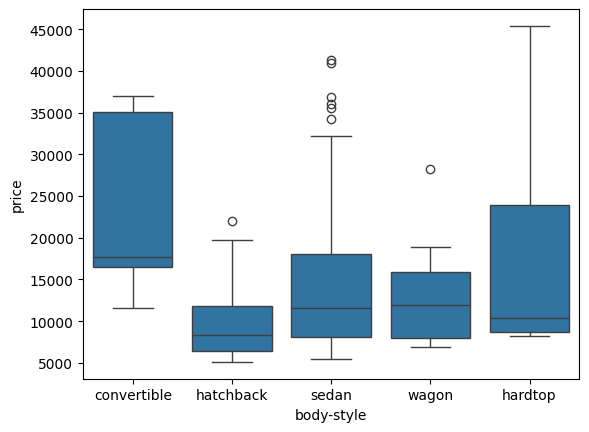

In [69]:
sns.boxplot(x="body-style", y="price", data=df)

<Axes: xlabel='engine-location', ylabel='price'>

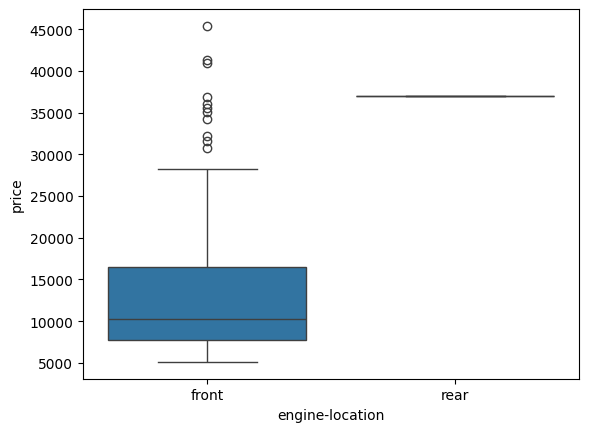

In [70]:
sns.boxplot(x="engine-location", y="price", data=df)

<Axes: xlabel='drive-wheels', ylabel='price'>

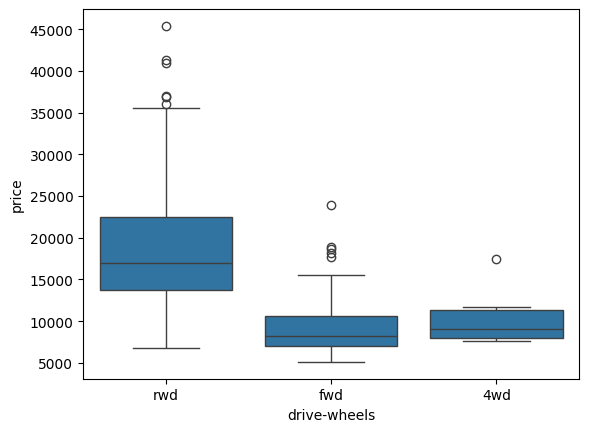

In [71]:
sns.boxplot(x="drive-wheels", y="price", data=df)

# Descriptive Statistical Analysis

### Let's first take a look at the variables by utilizing a description method.
### The describe function automatically computes basic statistics for all continuous variables. Any NaN values are automatically skipped in these statistics.
### This will show:
    the count of that variable
    the mean
    the standard deviation (std)
    the minimum value
    the IQR (Interquartile Range: 25%, 50% and 75%)
    the maximum value